### Data Loading and Initial Inspection
In this block, we import the necessary libraries, load our core dataset nasa.csv, and output its initial shape alongside the balance of our target variable Hazardous to understand our class distribution.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/nasa.csv')
print(f"Dataset Shape: {df.shape}")

print("\nClass Imbalance (Hazardous):")
print(df['Hazardous'].value_counts(normalize=True) * 100)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (4687, 40)

Class Imbalance (Hazardous):
Hazardous
False    83.891615
True     16.108385
Name: proportion, dtype: float64
Dataset Shape: (4687, 40)


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


### Data Cleaning
Here we remove redundant or unnecessary columns that either have duplicated information in different units or represent unique IDs and dates that do not contribute meaningfully to asteroid classification.

In [30]:
columns_to_drop = [
    'Est Dia in M(min)', 'Est Dia in M(max)', 
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hr', 'Miles per hour',
    'Equatorial Node', 
    'Orbiting Body',   
    'Neo Reference ID', 'Name', 
    'Close Approach Date', 'Orbit Determination Date', 'Equinox', 
    'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(miles)' 
]

df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

print(f"New Dataset Shape after dropping redundancy: {df_cleaned.shape}")

df_cleaned.head()

New Dataset Shape after dropping redundancy: (4687, 23)


,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Epoch Date Close Approach,Relative Velocity km per sec,Miss Dist.(kilometers),Orbit ID,Orbit Uncertainity,Minimum Orbit Intersection,Jupiter Tisserand Invariant,...,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Hazardous
0,21.6,0.127220,0.284472,788947200000,6.115834,62753692.0,17,5,0.025282,4.634,...,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,True
1,21.3,0.146068,0.326618,788947200000,18.113985,57298148.0,21,3,0.186935,5.457,...,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,False
2,20.3,0.231502,0.517654,789552000000,7.590711,7622911.5,22,0,0.043058,4.557,...,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,True
3,27.4,0.008801,0.019681,790156800000,11.173874,42683616.0,7,6,0.005512,5.093,...,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,False
4,21.6,0.127220,0.284472,790156800000,9.840831,61010824.0,25,1,0.034798,5.154,...,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,True


### Data Splitting and Feature Scaling
We separate our target variable (`Hazardous`) from the features, subsequently splitting the records into training and testing sets. We then apply `StandardScaler` to normalize the data properly.

In [31]:
X = df_cleaned.drop('Hazardous', axis=1)
y = df_cleaned['Hazardous'].astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")

Data successfully split and scaled!


### Save Cleaned Dataset
We now save a local copy of our cleaned pre-processed data to `nasa_cleaned.csv` to ensure consistent data usage in training and other notebooks.

In [32]:
df_cleaned.to_csv('../data/nasa_cleaned.csv', index=False)
print("Cleaned dataset saved as nasa_cleaned.csv!")

Cleaned dataset saved as nasa_cleaned.csv!


### Target Variable Visualized
This block generates a countplot to visually depict the imbalance in our target variable (`Hazardous` vs `Safe`).

C:\Users\Edwar\AppData\Local\Temp\ipykernel_22844\3575979519.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Hazardous', palette=['#2ecc71', '#e74c3c']) # Green for safe, Red for danger


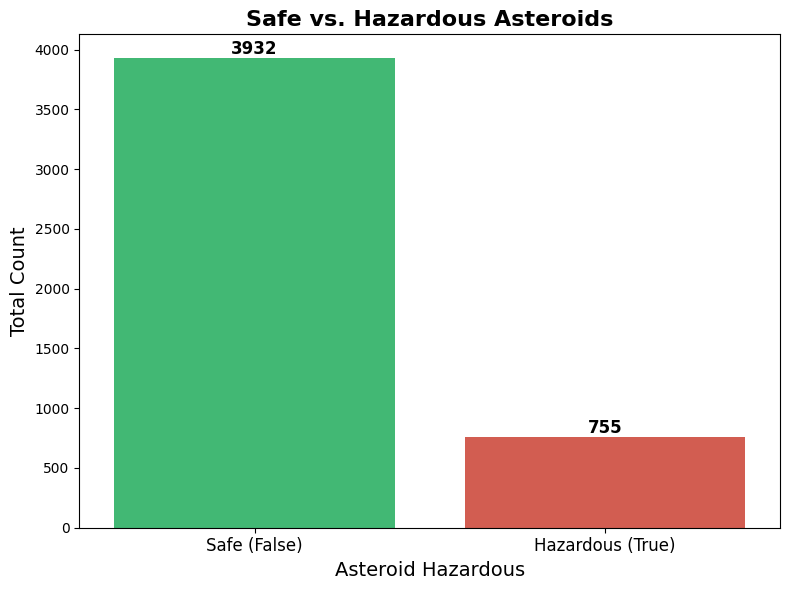

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='Hazardous', palette=['#2ecc71', '#e74c3c']) # Green for safe, Red for danger

plt.title('Safe vs. Hazardous Asteroids', fontsize=16, fontweight='bold')
plt.xlabel('Asteroid Hazardous', fontsize=14)
plt.ylabel('Total Count', fontsize=14)

plt.xticks([0, 1], ['Safe (False)', 'Hazardous (True)'], fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Correlation Analysis: Top and Bottom Features
We select the features displaying the highest positive and negative correlations to whether an asteroid is categorized as Hazardous, plotting them in a bar chart for quick insights.

C:\Users\Edwar\AppData\Local\Temp\ipykernel_22844\2309643031.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bottom_corr.values, y=top_bottom_corr.index, palette='coolwarm')


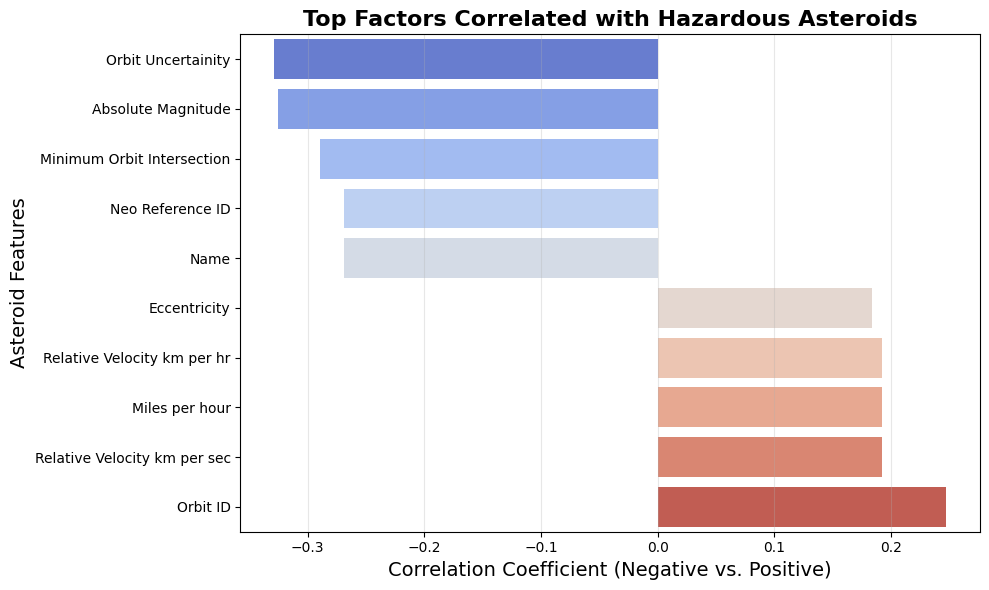

In [34]:
plt.figure(figsize=(10, 6))

correlations = df.corr(numeric_only=True)['Hazardous'].drop('Hazardous').sort_values()

top_bottom_corr = pd.concat([correlations.head(5), correlations.tail(5)])

sns.barplot(x=top_bottom_corr.values, y=top_bottom_corr.index, palette='coolwarm')

plt.title('Top Factors Correlated with Hazardous Asteroids', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient (Negative vs. Positive)', fontsize=14)
plt.ylabel('Asteroid Features', fontsize=14)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Feature Insight: Minimum Orbit Intersection
Using a box plot, we observe the difference in distribution of the `Minimum Orbit Intersection` feature specifically between the Safe and Hazardous classes.

C:\Users\Edwar\AppData\Local\Temp\ipykernel_22844\190779251.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hazardous', y=feature_to_plot, palette=['#2ecc71', '#e74c3c'])


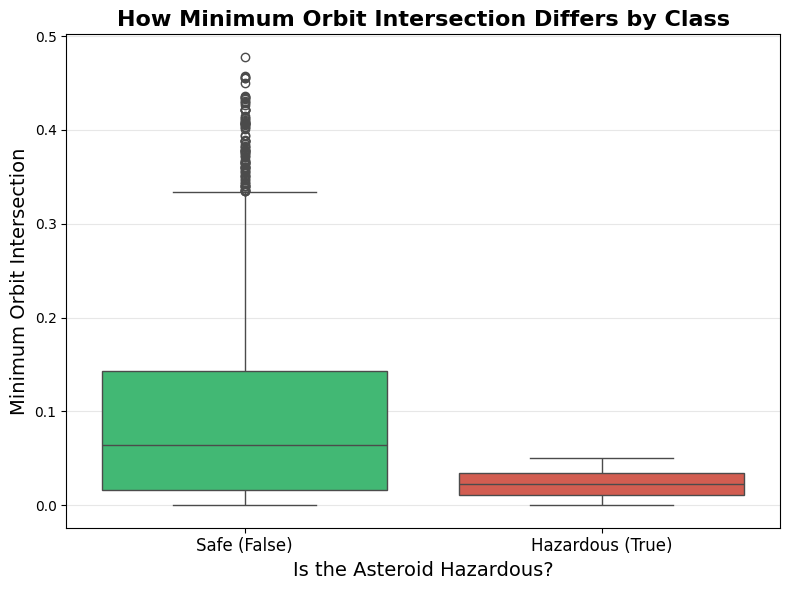

In [35]:
plt.figure(figsize=(8, 6))

feature_to_plot = 'Minimum Orbit Intersection'

sns.boxplot(data=df, x='Hazardous', y=feature_to_plot, palette=['#2ecc71', '#e74c3c'])

plt.title(f'How {feature_to_plot} Differs by Class', fontsize=16, fontweight='bold')
plt.xlabel('Is the Asteroid Hazardous?', fontsize=14)
plt.ylabel(feature_to_plot, fontsize=14)
plt.xticks([0, 1], ['Safe (False)', 'Hazardous (True)'], fontsize=12)
plt.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

### Full Correlation Matrices
Finally, we display clear visualizations of full correlation matrices: one for the raw dataset and another for the formally cleaned dataset, to see the overall change in feature collinearities.

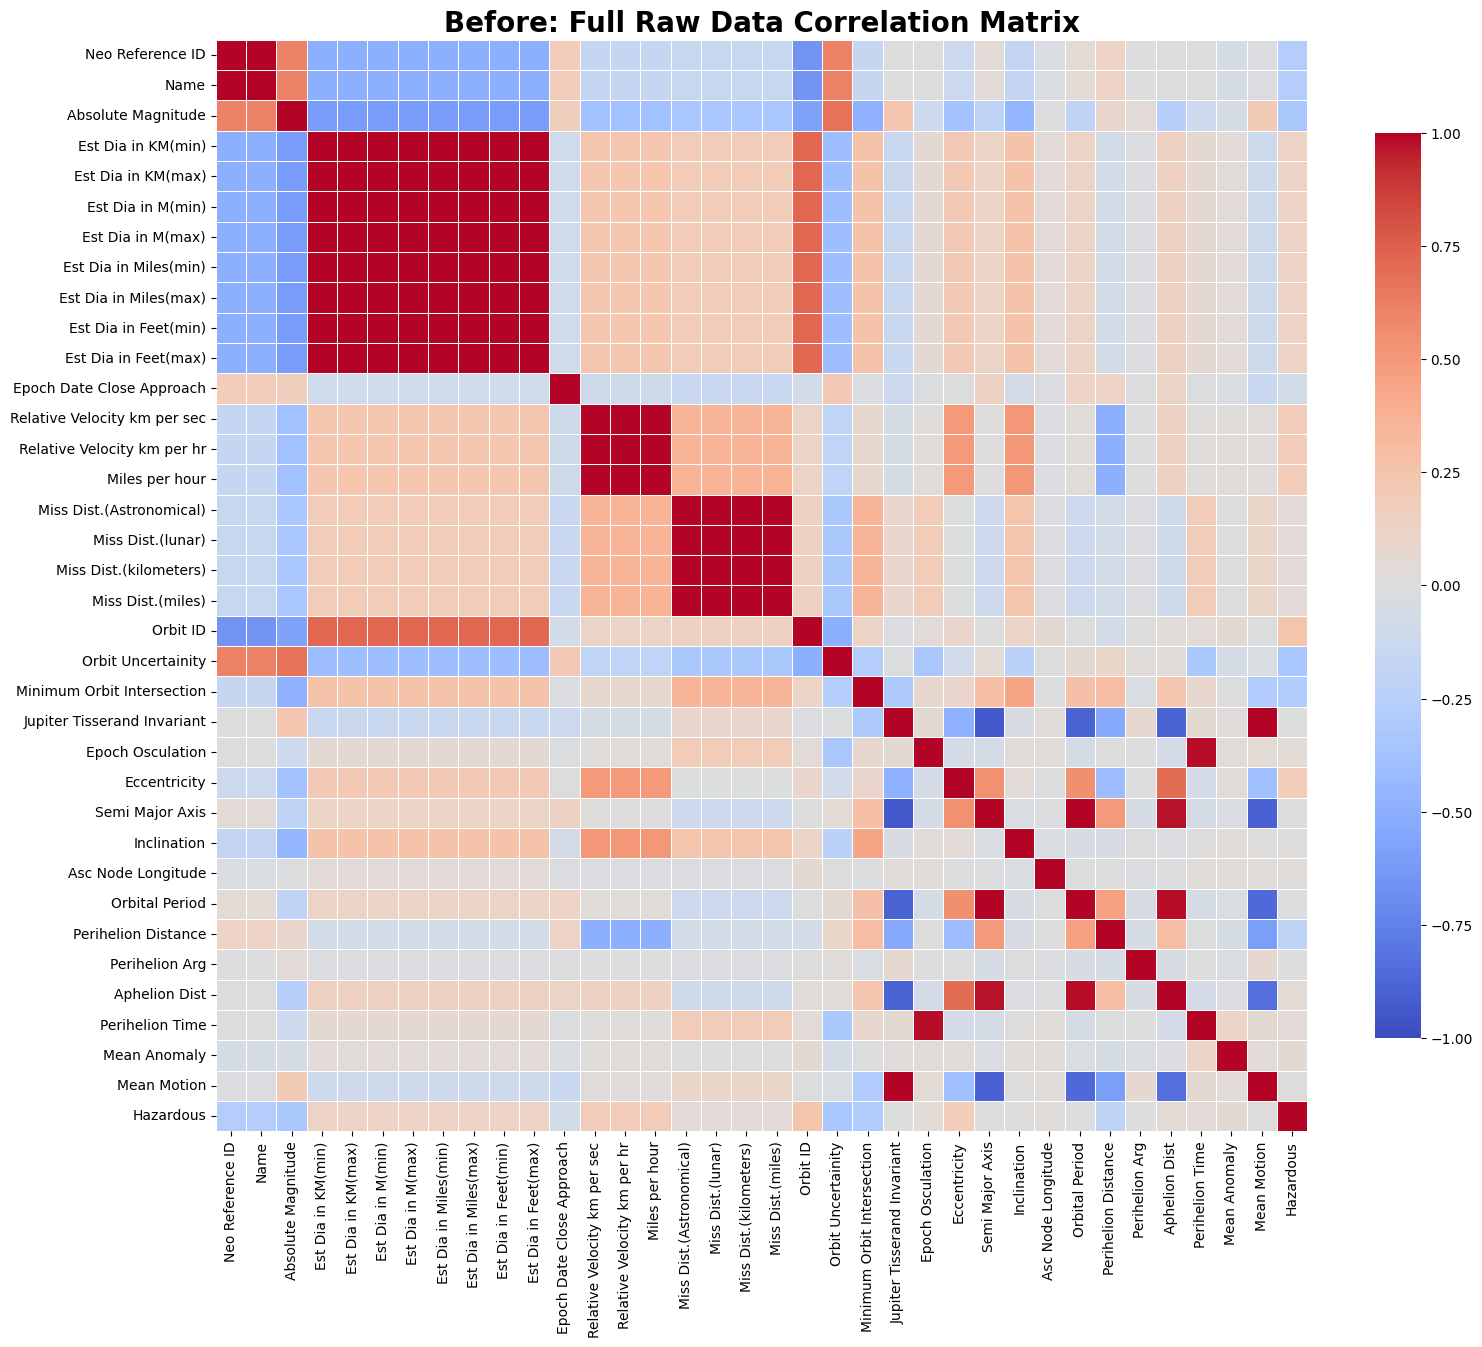

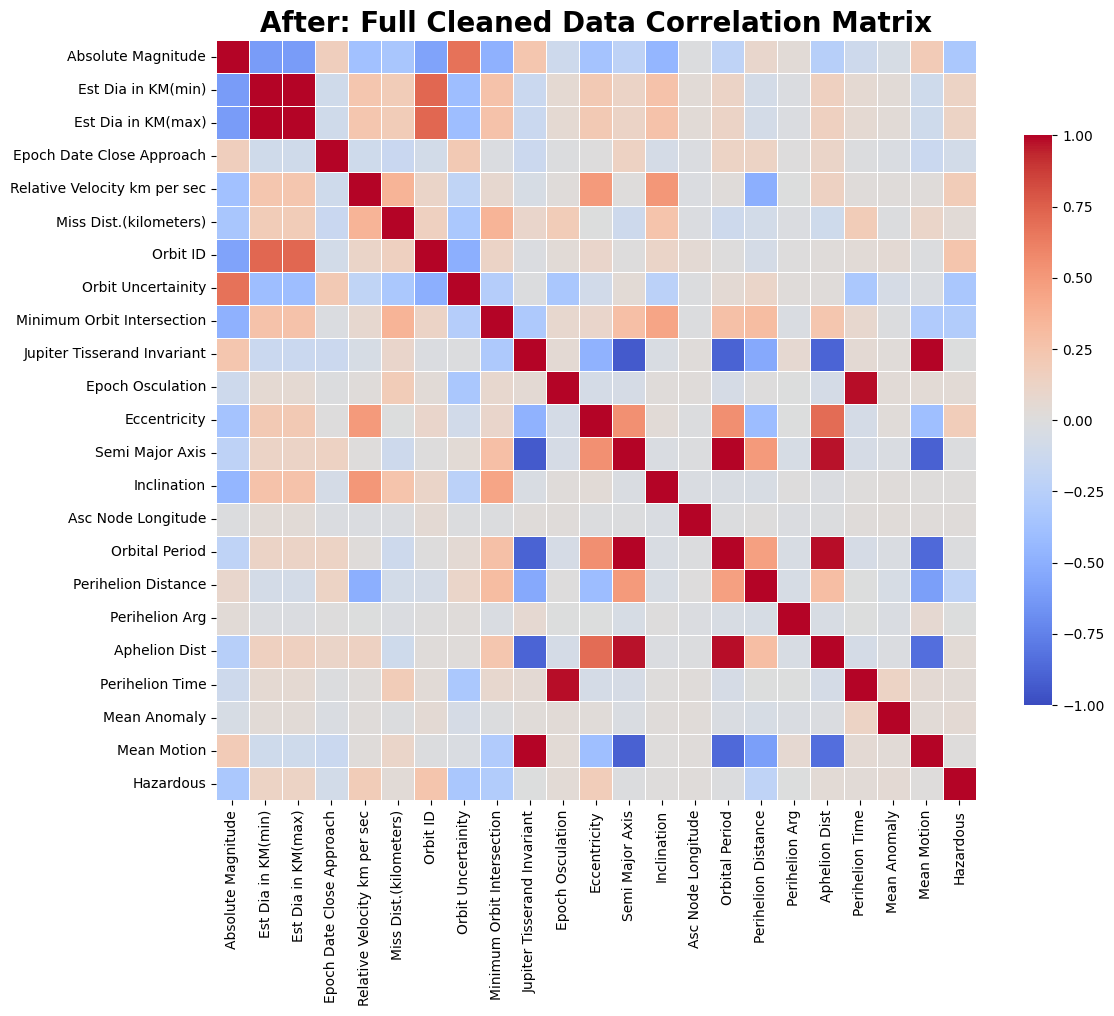

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(16, 14))

corr_raw = df.corr(numeric_only=True)

sns.heatmap(corr_raw, cmap='coolwarm', vmax=1.0, vmin=-1.0, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.75})

plt.title('Before: Full Raw Data Correlation Matrix', fontsize=20, fontweight='bold')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()


plt.figure(figsize=(12, 10))

corr_cleaned = df_cleaned.corr(numeric_only=True)

sns.heatmap(corr_cleaned, cmap='coolwarm', vmax=1.0, vmin=-1.0, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.75})

plt.title('After: Full Cleaned Data Correlation Matrix', fontsize=20, fontweight='bold')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()